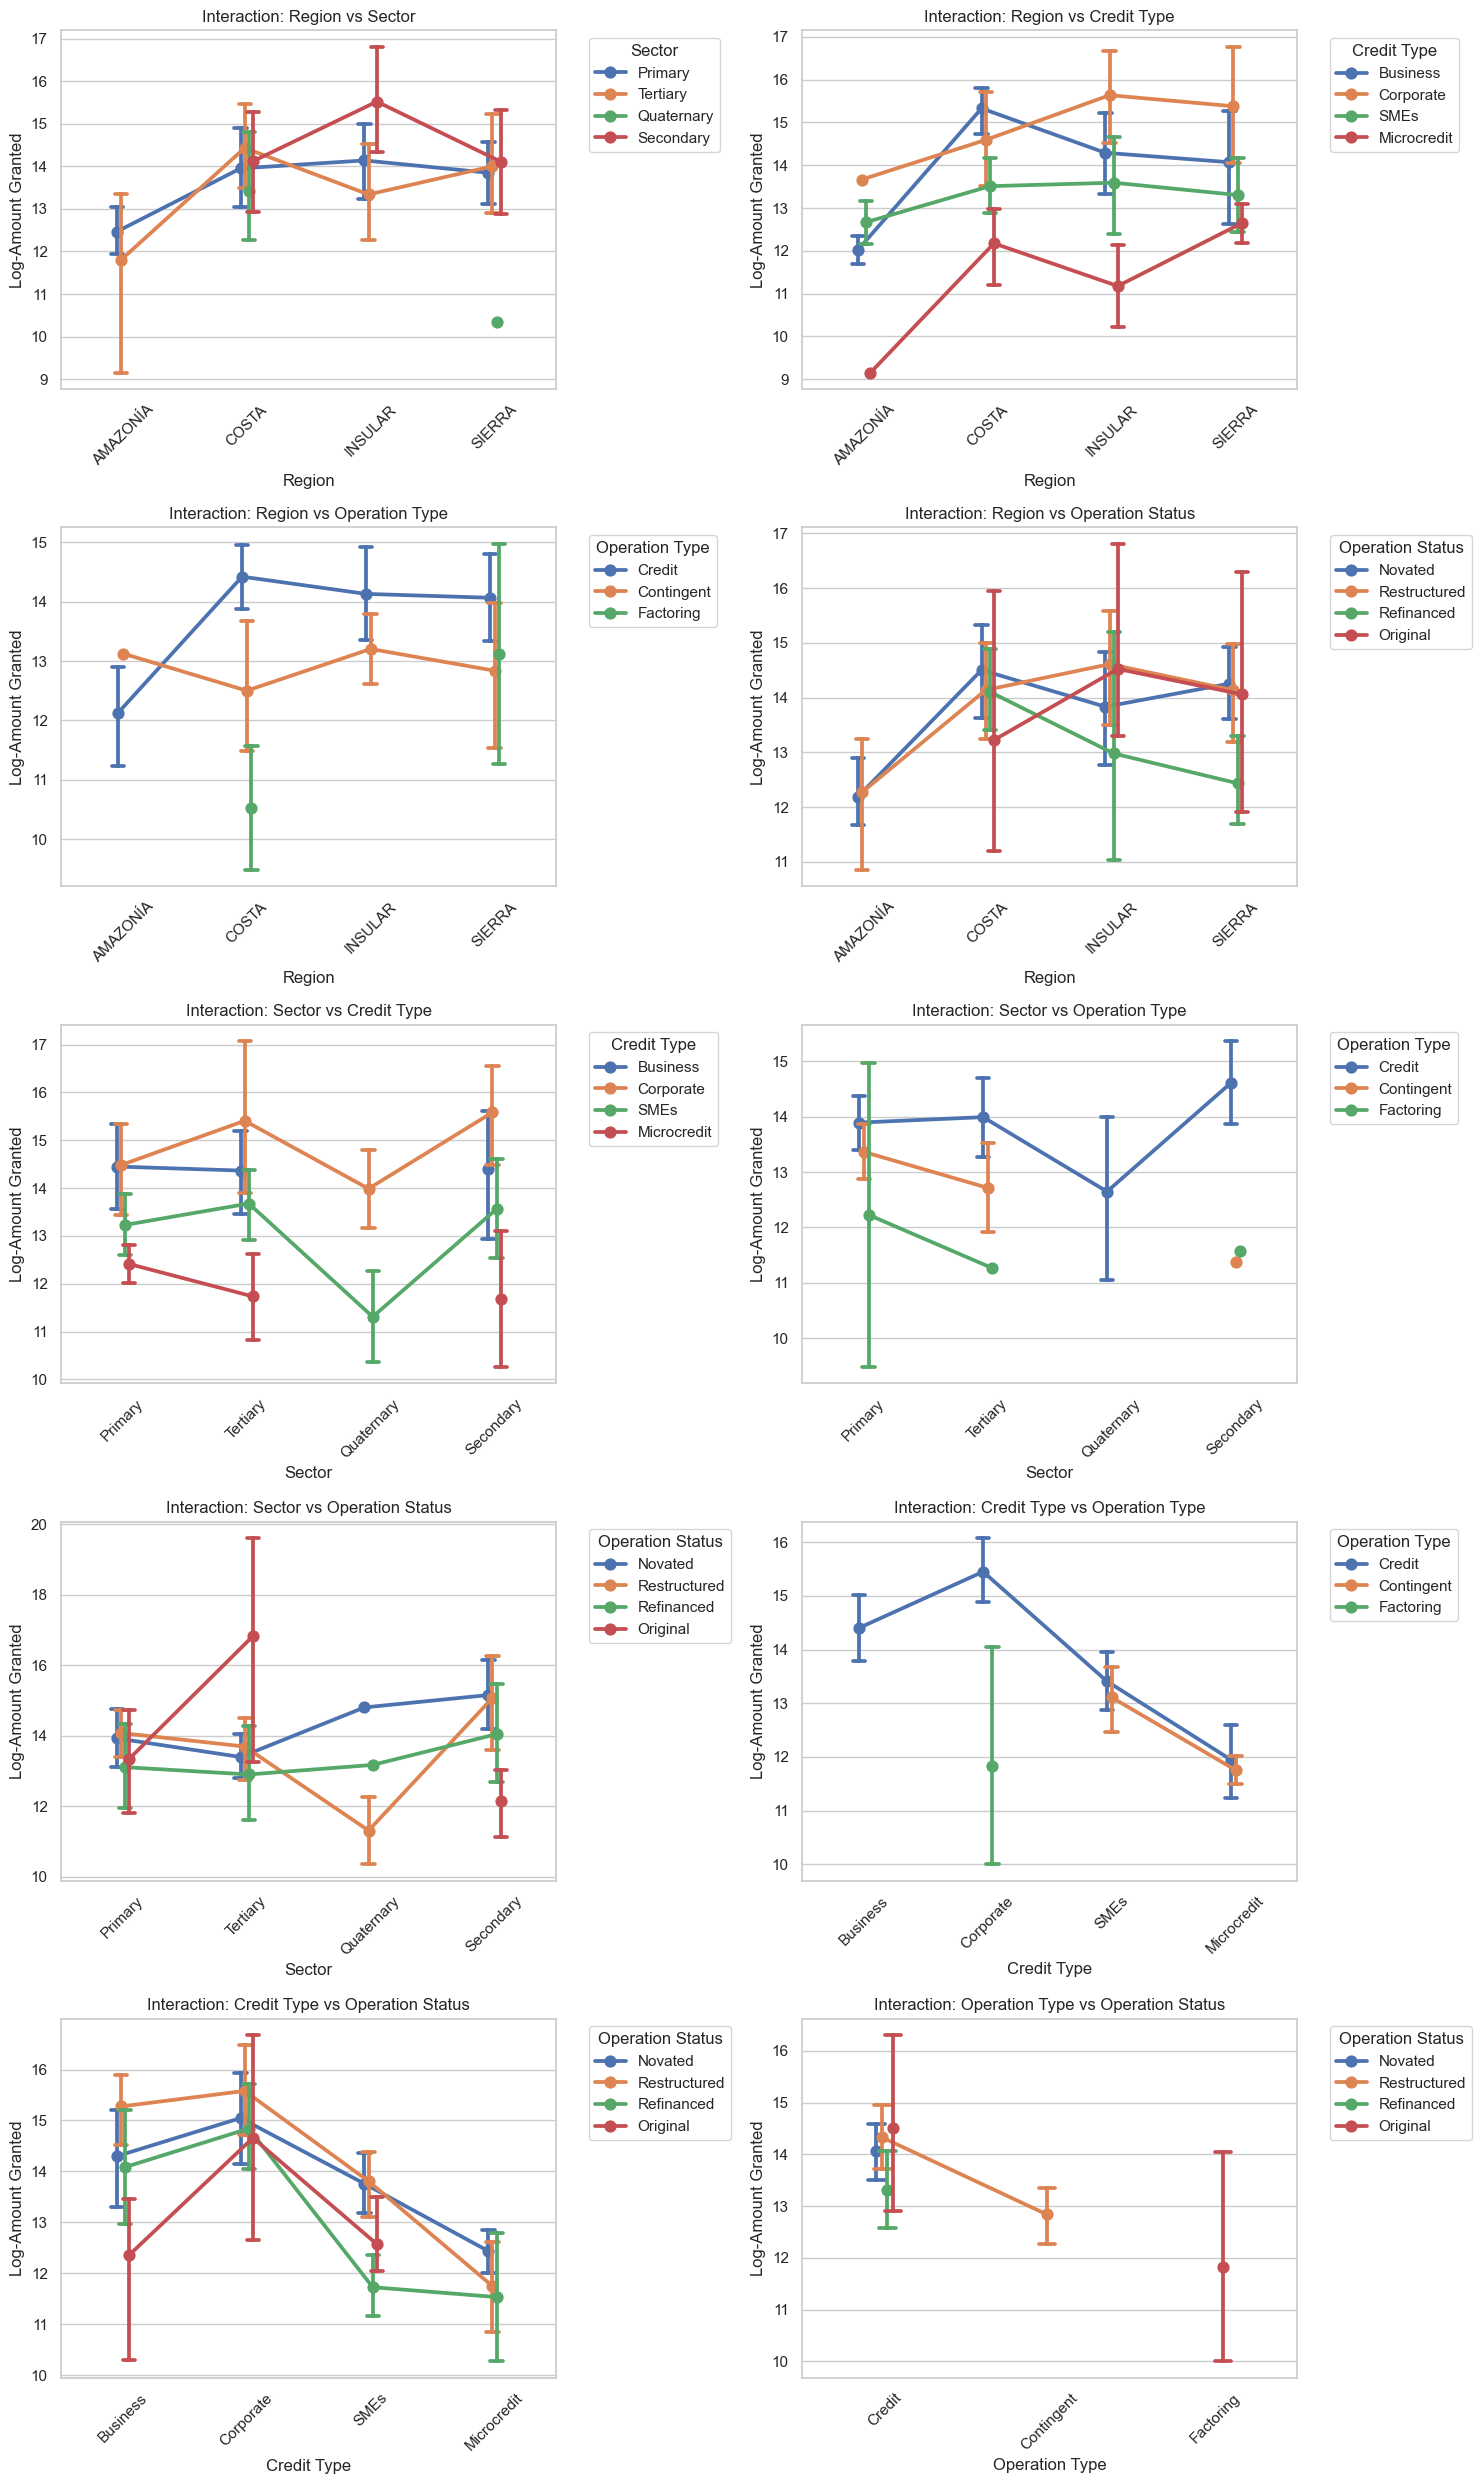

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

# 1. Load the dataset
df = pd.read_csv('cleaned_cfn_volumencreditocontingente_2025_enero-septiembre.csv')

# 2. Define the factors and generate the 10 unique pairs
sns.set_theme(style="whitegrid")
factors = ['Region', 'Sector', 'Credit Type', 'Operation Type', 'Operation Status']
pairs = list(itertools.combinations(factors, 2))

# 3. Set up a 5x2 grid for the 10 plots
fig, axes = plt.subplots(5, 2, figsize=(15, 25))
axes = axes.flatten()

# 4. Loop through the pairs and plot each interaction
for i, (factor1, factor2) in enumerate(pairs):
    # pointplot is ideal for interaction graphs because it connects the categories
    sns.pointplot(
        data=df, 
        x=factor1, 
        y='Log-Amount Granted', 
        hue=factor2, 
        dodge=True, 
        capsize=.1, 
        ax=axes[i], 
        errorbar=('ci', 95)  # Removed error bars for cleaner line comparison; remove this argument to see confidence intervals
    )
    
    # 5. Formatting
    axes[i].set_title(f'Interaction: {factor1} vs {factor2}')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Move the legend outside the plot so it doesn't overlap with the lines
    axes[i].legend(title=factor2, bbox_to_anchor=(1.05, 1), loc='upper left')

# 6. Save the final figure
plt.tight_layout()
plt.savefig('all_10_interactions.png', bbox_inches='tight')

In [6]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 2. Clean column names so they work smoothly with statsmodels formulas
# This converts 'Log-Amount Granted' to 'Log_Amount_Granted', etc.
df.columns = [c.replace(' ', '_').replace('-', '_') for c in df.columns]

# 3. Define the Partial Interaction Model
# Notice how we include all main effects, plus the specific interaction term at the end
formula = (
    'Log_Amount_Granted ~ C(Region) + C(Sector) + C(Credit_Type) + '
    'C(Operation_Type) + C(Operation_Status) + C(Region):C(Credit_Type)'
)

# 4. Fit the Ordinary Least Squares (OLS) model
model = ols(formula, data=df).fit()

# 5. Generate and print the ANOVA table (Type II is standard for this kind of design)
anova_table = sm.stats.anova_lm(model, typ=2)

print("ANOVA Table for Region vs Credit Type Interaction:")
print(anova_table)

ANOVA Table for Region vs Credit Type Interaction:
                              sum_sq    df          F        PR(>F)
C(Region)                  32.784951   3.0   5.292574  2.015447e-03
C(Sector)                  15.118145   3.0   2.440568  6.894449e-02
C(Credit_Type)            158.255617   3.0  25.547684  2.894435e-12
C(Operation_Type)          47.062425   2.0  11.396145  3.586155e-05
C(Operation_Status)        38.808372   3.0   6.264953  6.229290e-04
C(Region):C(Credit_Type)   23.508562   9.0   1.265019  2.658081e-01
Residual                  200.289450  97.0        NaN           NaN
